In [ ]:
#bibliotecas para modelagem de dados
import pandas as pd
import numpy as np

#bibliotecas para analises graficas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from cycler import cycler

#bibliotecas para criação do modelo de aprendizado
from scipy.sparse import csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

#bibliotecas para criação do cluster
from sklearn.cluster import KMeans
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [ ]:
#Criar paleta personalizada
netflix_palette = [
    "#e5383b",
    "#a2010b",
    "#e8843f",
    "#0f6092",
    "#010103",
    "#F1948A",
    "#85929E"
]

plt.rcParams['axes.prop_cycle'] = cycler(color=netflix_palette)

In [ ]:
#importar dados
df=pd.read_csv('/content/dataset_final.csv')
df.head()

,id,tipo,titulo,diretor,elenco,pais,adicionado_em,ano_lancamento,classificacao,genero,data_lancamento,duracao_em_min,temporadas,estacao
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,"Richard Johnson, Kirsten Johnson, Isla Sierck,...",US,2021-09-25,2020,12,Documentaries,2020-01-23,90.0,NaN,Verão
1,s2,TV Show,Blood & Water,Não Informado,"Ama Qamata, Khosi Ngema, Gail Mabalane, Dillon...",ZA,2021-09-24,2021,18,"International TV Shows, TV Dramas, TV Mysteries",2020-05-20,NaN,2.0,Outono
2,s3,TV Show,Ganglands,Não Informado,"Sami Bouajila, Tracy Gotoas, Salim Kéchiouche,...",FR,2021-09-24,2021,18,"Crime TV Shows, International TV Shows, TV Act...",2021-09-24,NaN,1.0,Primavera
3,s4,TV Show,Jailbirds New Orleans,Não Informado,Não Informado,US,2021-09-24,2021,18,"Docuseries, Reality TV",2021-09-24,NaN,1.0,Primavera
4,s5,TV Show,Kota Factory,Não Informado,"Jitendra Kumar, Mayur More, Ranjan Raj, Alam K...",IN,2021-09-24,2021,18,"International TV Shows, Romantic TV Shows, TV ...",2019-04-16,NaN,2.0,Outono


#Análises iniciais

In [ ]:
#Classificação x Duração
fig = px.scatter(
    data_frame=df,
    y='classificacao',
    x='duracao_em_min',
    title= 'Classificação x Duração',
    #Acrescentar histograma acima do gráfico principal
    marginal_x='histogram',
    color_discrete_sequence=netflix_palette
)

fig.update_layout(
    plot_bgcolor="#f5f3f4"
)

<Axes: title={'center': 'Distribuição de classificações'}, xlabel='classificacao'>

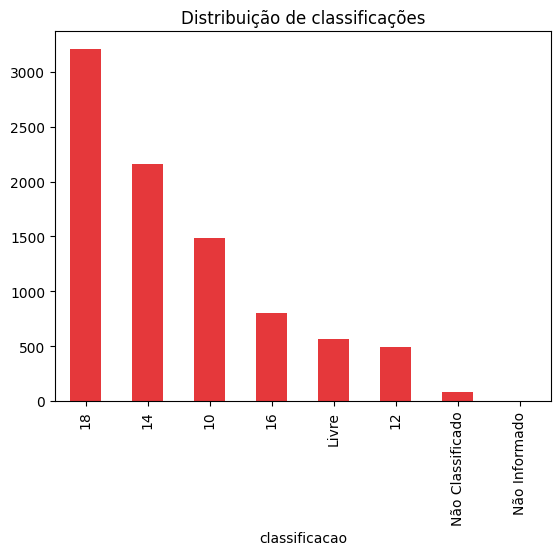

In [ ]:
df['classificacao'].value_counts().plot(kind='bar',title='Distribuição de classificações')

#Correlação Classificação x Duração

In [ ]:
#Criar um df apenas com os filmes
df_filmes = df[df["tipo"] == "Movie"].copy()
df_filmes.head(1)

,id,tipo,titulo,diretor,elenco,pais,adicionado_em,ano_lancamento,classificacao,genero,data_lancamento,duracao_em_min,temporadas,estacao
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,"Richard Johnson, Kirsten Johnson, Isla Sierck,...",US,2021-09-25,2020,12,Documentaries,2020-01-23,90.0,NaN,Verão


In [ ]:
#Transformar classificações em número (facilita para a correlação)
mapa_numerico = {
    "Não Classificado" : 0,
    "Livre": 1,
    "10": 10,
    "12": 12,
    "14": 14,
    "16": 16,
    "18": 18
}

#Remove não informado da lista
df_filmes = df_filmes[
    df_filmes["classificacao"].isin(["Não Classificado", "Livre", "10", "12", "14", "16", "18"])].copy()
df_filmes["classificacao_num"] = df_filmes["classificacao"].map(mapa_numerico)

#Ordenar lista para facilitar a visualização nos gráficos
ordem_classificacao = ["18","16","14","12","10","Livre", "Não Classificado"]

df_filmes["classificacao"] = pd.Categorical(
    df_filmes["classificacao"],
    categories=ordem_classificacao,
    ordered=True
)

In [ ]:
#Correlação geral entre classificação indicativa e duração
correlacao = df_filmes[['duracao_em_min','classificacao_num']].corr(method='spearman')

correlacao

,duracao_em_min,classificacao_num
duracao_em_min,1.000000,0.047463
classificacao_num,0.047463,1.000000


In [ ]:
#Correlação entre cada classificação indicativa e duração (positiva = filmes + longos, negativa = filmes + curtos)
dummies = pd.get_dummies(df_filmes["classificacao_num"]) #Precisa dos dummies para ver cada classificação individualmente

correlacao_detalhe = pd.concat([df_filmes["duracao_em_min"], dummies], axis=1)

correlacao_detalhe.corr(method="spearman")

#Análise: a correlação é fraca, mas há uma tendência leve de classificações mais altas terem maior duração

,duracao_em_min,0,1,10,12,14,16,18
duracao_em_min,1.000000,-0.030919,-0.234119,-0.127176,0.112010,0.201930,0.112693,-0.112913
0,-0.030919,1.000000,-0.025680,-0.049287,-0.033485,-0.062582,-0.043919,-0.080981
1,-0.234119,-0.025680,1.000000,-0.098139,-0.066675,-0.124611,-0.087449,-0.161247
10,-0.127176,-0.049287,-0.098139,1.000000,-0.127970,-0.239169,-0.167842,-0.309484
12,0.112010,-0.033485,-0.066675,-0.127970,1.000000,-0.162488,-0.114030,-0.210260
14,0.201930,-0.062582,-0.124611,-0.239169,-0.162488,1.000000,-0.213116,-0.392964
16,0.112693,-0.043919,-0.087449,-0.167842,-0.114030,-0.213116,1.000000,-0.275772
18,-0.112913,-0.080981,-0.161247,-0.309484,-0.210260,-0.392964,-0.275772,1.000000


In [ ]:
#Visualizar correlação com linha de tendência
fig = px.scatter(
    df_filmes,
    x="duracao_em_min",
    y="classificacao_num",
    hover_data=["titulo"],
    trendline="ols",
    title="Relação entre duração e classificação indicativa",
    color_discrete_sequence=netflix_palette
)

fig.update_layout(
    plot_bgcolor="#f5f3f4"
)

#Agrupar filmes semelhantes
Duração x Classificação

In [ ]:
#Selecionar informações que vamos usar para o Kmeans
X = df_filmes[["duracao_em_min", "classificacao_num"]]

#Colocar todos os números na mesma escala com o Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


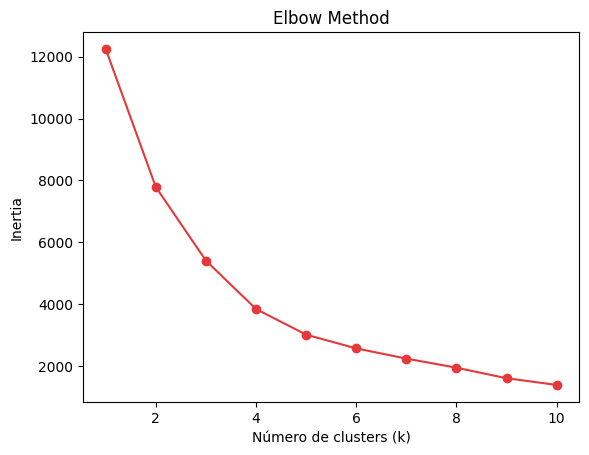

In [ ]:
#Aplicando o método elbow pra saber a quantidade ideal de clusters pra estes dados
inertia = []
K = range(1, 11)

for k in K:
    modelo = KMeans(n_clusters=k, random_state=42)
    modelo.fit(X_scaled)
    inertia.append(modelo.inertia_)

plt.figure()

plt.plot(K, inertia, marker='o')

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [ ]:
#Criar clusters (agrupar filmes semelhantes)
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

#Adicionar coluna de cluster ao DF
df_filmes['cluster'] = clusters

In [ ]:
#Visualizar clusters
fig = px.scatter(
    df_filmes,
    x="duracao_em_min",
    y="classificacao_num",
    color="cluster",
    hover_data=["titulo", "classificacao", "duracao_em_min"],
    title="Clusterização de filmes por duração e classificação",
    category_orders={
        "classificacao_br": ["18","16","14","12","10","Livre"],
        "cluster": ["0","1","2","3"]
    }
)

fig.update_layout(
    plot_bgcolor="#f5f3f4"
)

fig.show()
#Cluster 0 = classificação 10 a 14, até +- 117 min
#Cluster 1 = classificação 16 a 18, até +- 120 min
#Cluster 2 = classificação livre e não classificado, até 146 min
#Cluster 3 = classificação livre a 18, a partir de +- 120 min

Text(0.5, 1.0, 'Características por cluster')

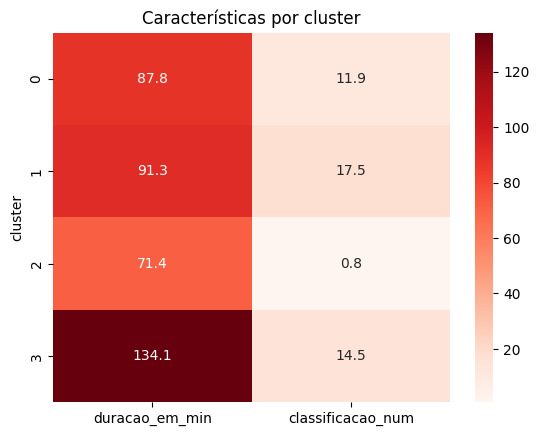

In [ ]:
#Duração e classificação por cluster
cluster_info = df_filmes.groupby("cluster")[["duracao_em_min","classificacao_num"]].mean()

sns.heatmap(
    cluster_info,
    annot=True,
    cmap="Reds",
    fmt=".1f"
)

plt.title("Características por cluster")

<Axes: title={'center': 'Distribuição de filmes por cluster'}, xlabel='cluster'>

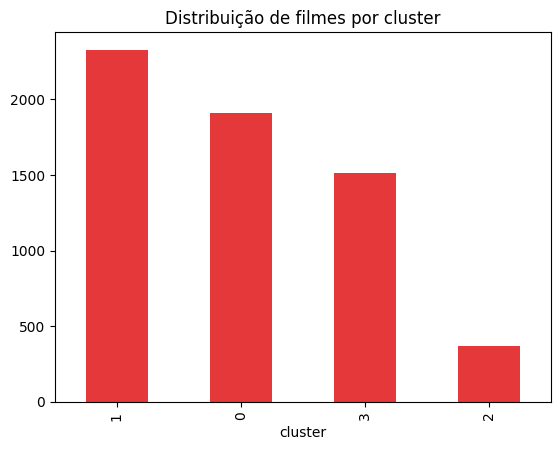

In [ ]:
#Distribuição de filmes por cluster
df_filmes['cluster'].value_counts().plot(kind='bar',title='Distribuição de filmes por cluster')

## Achados

O cluster com menor número de filmes é o 2: filmes curtos com indicação livre, ou não classificados.

O cluster com maior número de filmes é o 1: filmes curtos de classificação 16 e 18.

O cluster com maior média de duração é o 3 e ele inclui filmes de 4 classificações (maior variedade de classificações entre todos os clusters)

#Agrupar filmes semelhantes 2.0
Duração x Classificação x Gênero

In [ ]:
#Preparar coluna de gêneros para as análises, vamos utilizar apenas o top 10 para facilitar a visualização
#Separar gêneros
df_filmes["genero"] = df_filmes["genero"].str.split(", ")

#Explodir lista de gêneros
generos_explodidos = df_filmes.explode("genero")

#Encontrar o top 10
top10_generos = generos_explodidos["genero"].value_counts().head(10).index

#Usar dummies para transformar gênero em número
genero_dummies = pd.get_dummies(generos_explodidos["genero"])

#Colocar a linha explodida de volta no lugar
genero_por_filme = genero_dummies.groupby(generos_explodidos["id"]).sum()

#Separar o top 10
genero_por_filme = genero_por_filme[top10_generos]

#Juntar top 10 ao df_filmes
df_filmes = df_filmes.set_index("id").join(genero_por_filme)

In [ ]:
#Selecionando as informações para o Kmeans
X = df_filmes[["duracao_em_min", "classificacao_num"] + list(top10_generos)]

#Escalar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Rodar o Kmeans
kmeans = KMeans(n_clusters=7, random_state=42)
df_filmes["cluster"] = kmeans.fit_predict(X_scaled)

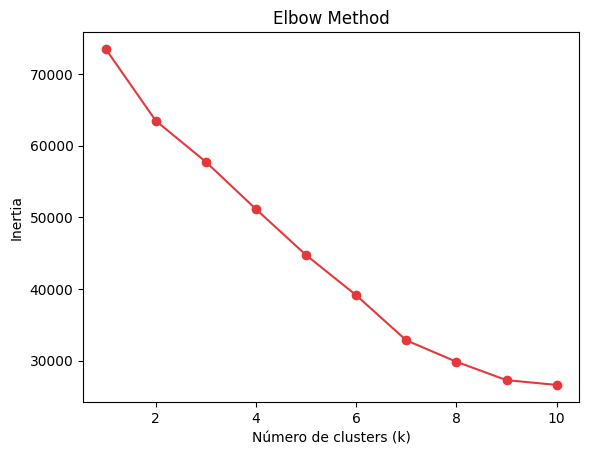

In [ ]:
#Aplicando o método elbow pra saber a quantidade ideal de clusters pra estes dados
inertia = []
K = range(1, 11)

for k in K:
    modelo = KMeans(n_clusters=k, random_state=42)
    modelo.fit(X_scaled)
    inertia.append(modelo.inertia_)

plt.figure()

plt.plot(K, inertia, marker='o')

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

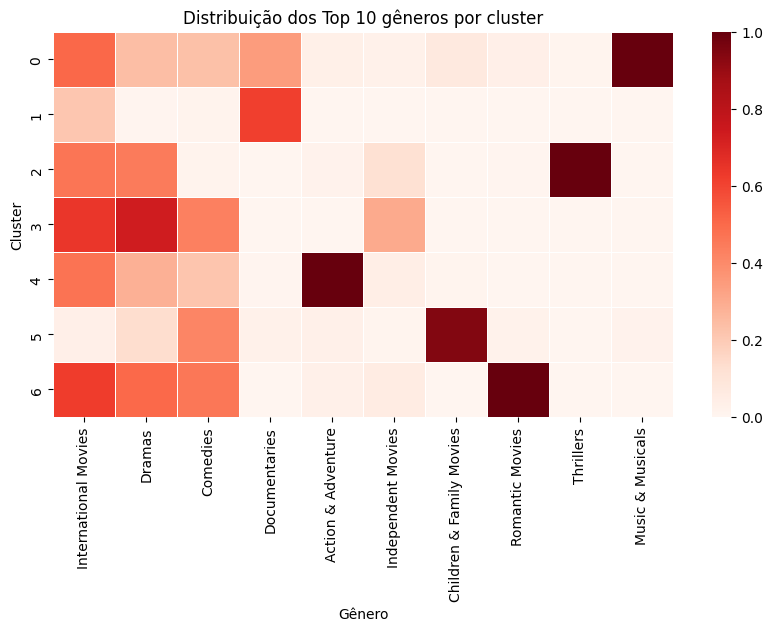

In [ ]:
#Visualizar distribuição dos gêneros nos clusters
cluster_generos = df_filmes.groupby("cluster")[top10_generos].mean()

plt.figure(figsize=(10,5))
sns.heatmap(
    cluster_generos,
    cmap="Reds",
    linewidths=0.5)

plt.title("Distribuição dos Top 10 gêneros por cluster")
plt.xlabel("Gênero")
plt.ylabel("Cluster")

plt.show()

Text(0.5, 1.0, 'Características por cluster')

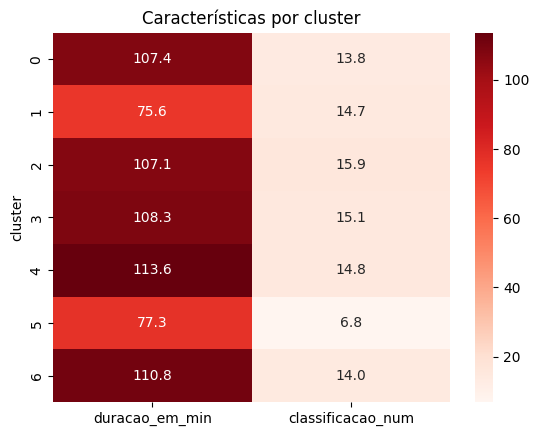

In [ ]:
#Duração e classificação por cluster
cluster_info = df_filmes.groupby("cluster")[["duracao_em_min","classificacao_num"]].mean()

sns.heatmap(
    cluster_info,
    annot=True,
    cmap="Reds",
    fmt=".1f"
)

plt.title("Características por cluster")

<Axes: title={'center': 'Distribuição de clusters'}, xlabel='cluster'>

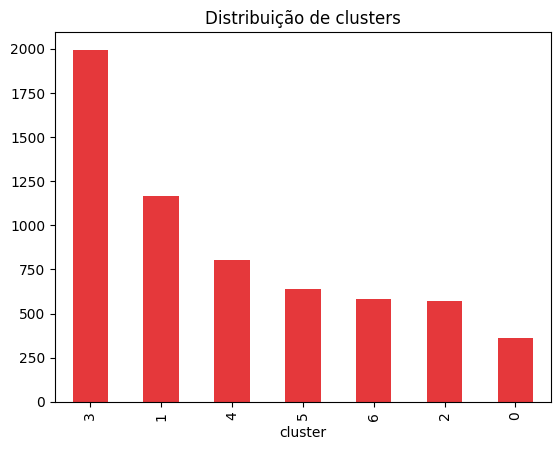

In [ ]:
#Ver quantidade de filmes por cluster
df_filmes['cluster'].value_counts().plot(kind='bar',title='Distribuição de clusters')

In [ ]:
#Visualizar novos clusters no scatterplot
df_filmes["cluster"] = df_filmes["cluster"].astype(str)

fig = px.scatter(
    df_filmes,
    x="duracao_em_min",
    y="classificacao_num",
    color="cluster",
    hover_data=["titulo"],
    title="Clusterização de filmes",
    category_orders={
        "cluster": ["0","1","2","3","4","5","6"]
    },
    color_discrete_sequence=netflix_palette
)

fig.update_layout(
    plot_bgcolor="#f5f3f4"
)

fig.show()

In [ ]:
#Criar PCA para facilitar a visualização dos clusters no scatterplot
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

df_pca["cluster"] = df_filmes["cluster"].values
df_pca["titulo"] = df_filmes["titulo"].values

In [ ]:
#Transformar cluster em string para facilitar a legenda do gráfico
df_pca["cluster"] = df_pca["cluster"].astype(str)

#Ver scatterplot com PCA aplicado
fig = px.scatter(
    df_pca,
    x="PC1",
    y="PC2",
    color="cluster",
    hover_data=["titulo"],
    title="Clusterização de filmes",
    category_orders={
        "cluster": ["0","1","2","3","4","5","6"]
    },
    color_discrete_sequence=netflix_palette
)

fig.update_layout(
    plot_bgcolor="#f5f3f4"
)

fig.show()

In [ ]:
#Printar resumo

print("Resumo\n")

#média de duração e classificação
cluster_medias = df_filmes.groupby("cluster")[["duracao_em_min","classificacao_num"]].mean()

#média dos gêneros
cluster_generos = df_filmes.groupby("cluster")[top10_generos].mean()

for cluster in cluster_medias.index:

    duracao = round(cluster_medias.loc[cluster, "duracao_em_min"],1)
    classificacao = round(cluster_medias.loc[cluster, "classificacao_num"],1)

    #pegar os 3 gêneros mais presentes
    top_generos = (
        cluster_generos.loc[cluster]
        .sort_values(ascending=False)
        .head(3)
        .index
        .tolist()
    )

    generos_texto = ", ".join(top_generos)

    print(f"Média Cluster {cluster}: Duração {duracao} min | Classificação {classificacao} | {generos_texto}")

Resumo

Média Cluster 0: Duração 107.4 min | Classificação 13.8 | Music & Musicals, International Movies, Documentaries
Média Cluster 1: Duração 75.6 min | Classificação 14.7 | Documentaries, International Movies, Comedies
Média Cluster 2: Duração 107.1 min | Classificação 15.9 | Thrillers, International Movies, Dramas
Média Cluster 3: Duração 108.3 min | Classificação 15.1 | Dramas, International Movies, Comedies
Média Cluster 4: Duração 113.6 min | Classificação 14.8 | Action & Adventure, International Movies, Dramas
Média Cluster 5: Duração 77.3 min | Classificação 6.8 | Children & Family Movies, Comedies, Dramas
Média Cluster 6: Duração 110.8 min | Classificação 14.0 | Romantic Movies, International Movies, Dramas


## Resumo

* Cluster 0: Duração média, Adolescentes
* Cluster 1: Duração curta, Jovens
* Cluster 2: Duração média, Adultos
* Cluster 3: Duração média, Jovens
* Cluster 4: Filmes longos, Adolescentes
* Cluster 5: Filmes curtos, Família
* Cluster 6: Filmes médios, Jovens